# DeiTIII training
This notebook trains an DeiTIII model for multi-class classification on the ERCP dataset.

In [1]:
from livelossplot import PlotLosses 
from livelossplot.outputs import MatplotlibPlot

%matplotlib inline
import matplotlib.pyplot as plt

from monai.transforms import (Activations, AsDiscrete, LoadImage, EnsureChannelFirst, Resize,
                                RandZoom, RandAdjustContrast, RandGaussianNoise, RandRotate,
                                ToTensor, Compose, NormalizeIntensity, Lambda)
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.utils import set_determinism
from monai.config import print_config

import numpy as np

import os

from PIL import Image

import random

import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

import timm
import time

import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torchmetrics.classification import MulticlassF1Score


np.random.seed(0)
set_determinism(seed=0)
print_config()

MONAI version: 1.5.2
Numpy version: 1.26.4
Pytorch version: 2.5.1+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: c:\Users\<username>\Desktop\Uni\MIA\Aprendizagem Profunda\Módulo II\Aprendizagem-Profunda---Trabalho-Pratico\venv\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.1.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.20.1+cu121
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 2.3.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT IN

In [2]:
model_name = './models/deitiii.pth'

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


In [4]:
import os
import pandas as pd
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# 1. Definir os caminhos
base_dir = '../dataset' 
processed_dir = os.path.join(base_dir, 'processed')
metadata_path = os.path.join(base_dir, 'metadata.csv')

# Ler o CSV
df = pd.read_csv(metadata_path)

# ==============================================================================
# FASE 1: LIMPEZA DE DADOS E MAPEAMENTO DE CLASSES
# ==============================================================================
print(f"Total de imagens original: {len(df)}")

# 1. Remover o lixo
df = df[(df['Keep'] == 'Keep') & (df['Label'] != 'Unlabelled')].copy()

# 2. O Dicionário Mágico: Traduzir o CSV para o formato do teu Enunciado
mapeamento_classes = {
    'Normal': 'Normal',
    'Lithiasis': 'Lithiasis',
    'Biliary Leaks': 'Biliary_Leaks',          # Tirar o espaço
    'Malignant Stricture': 'Stricture',        # Fundir as duas estenoses
    'Benign Stricture': 'Stricture'
}

# Aplicar o mapeamento (o que não estiver no dicionário vira NaN, mas não temos mais nada)
df['Label'] = df['Label'].map(mapeamento_classes)

# Garantir que só trabalhamos com as 4 classes pedidas (por segurança)
classes_alvo = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']
df = df[df['Label'].isin(classes_alvo)].copy()

print(f"Total de imagens após limpeza e fusão de classes: {len(df)}")
# Mostrar as quantidades de cada classe para confirmares que o desbalanceamento existe!
print("\nDistribuição das classes:")
print(df['Label'].value_counts())

# ==============================================================================
# FASE 2: SPLIT (Treino, Validação, Teste)
# ==============================================================================
# Dividir primeiro em 80% Treino e 20% (Temp)
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df['Label'], random_state=42)

# Dividir os 20% Temp em 10% Validação e 10% Teste
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['Label'], random_state=42)

# Assinalar a que split pertence cada linha
train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

# Juntar tudo num DataFrame final
df_final = pd.concat([train_df, val_df, test_df])

# ==============================================================================
# FASE 3: CRIAR PASTAS E COPIAR
# ==============================================================================
phases = ['train', 'val', 'test']
classes = df_final['Label'].unique()

# Criar diretorias
for phase in phases:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, phase, str(cls)), exist_ok=True)

# Copiar imagens
print("A organizar as imagens nas pastas corretas...")
erros = 0

for index, row in tqdm(df_final.iterrows(), total=df_final.shape[0]):
    filename = os.path.basename(str(row['processed_image_path']))
    img_class = str(row['Label'])
    img_split = str(row['split'])
    
    src = os.path.join(processed_dir, filename)
    dst = os.path.join(base_dir, img_split, img_class, filename)
    
    if os.path.exists(src):
        shutil.copy2(src, dst)
    else:
        erros += 1

print(f"\nOrganização concluída! Ficheiros não encontrados: {erros}")

Total de imagens original: 19317
Total de imagens após limpeza e fusão de classes: 1568

Distribuição das classes:
Label
Lithiasis        726
Stricture        392
Normal           299
Biliary_Leaks    151
Name: count, dtype: int64
A organizar as imagens nas pastas corretas...


100%|██████████| 1568/1568 [00:04<00:00, 373.39it/s]


Organização concluída! Ficheiros não encontrados: 0


## Dataset
Load dataset paths and compute class counts. This section populates `data` with `train`, `val`, and `test` image file lists and their labels.

In [5]:
base_dir = '../dataset'
phases = ['train', 'val', 'test']

data = {phase: {'images': [], 'labels': []} for phase in phases}
class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
#class_names = sorted([x for x in os.listdir(os.path.join(base_dir, 'train')) if os.path.isdir(os.path.join(base_dir, 'train', x))])
num_class = len(class_names)

def load_images_labels(phase):
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
        image_files = [
                            os.path.join(class_dir, x)
                            for x in os.listdir(class_dir)
                            if x.lower().endswith(valid_exts)
                        ]

        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count =", len(data[phase]['images']))
    

Train count = 1400
Val count = 244
Test count = 246


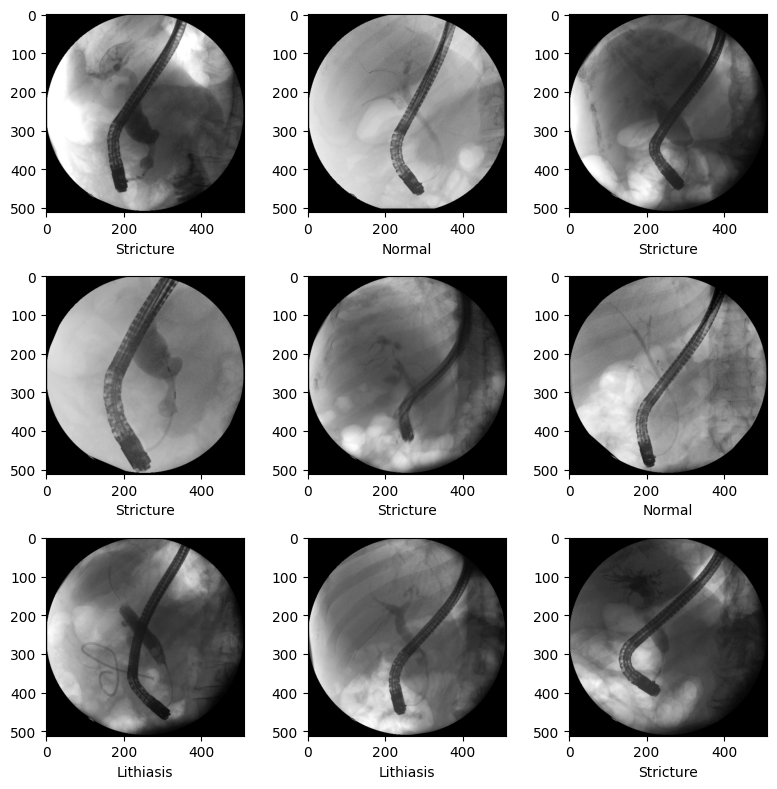

In [6]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(len(data['train']['images']), size=9)):
    im = Image.open(data['train']['images'][k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[data['train']['labels'][k]])
    plt.imshow(arr, cmap='gray', vmin=0, vmax=255)
plt.tight_layout()
plt.show()


----- TRAIN CASES -----
cases: 1400
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[121 682 284 313]
1400


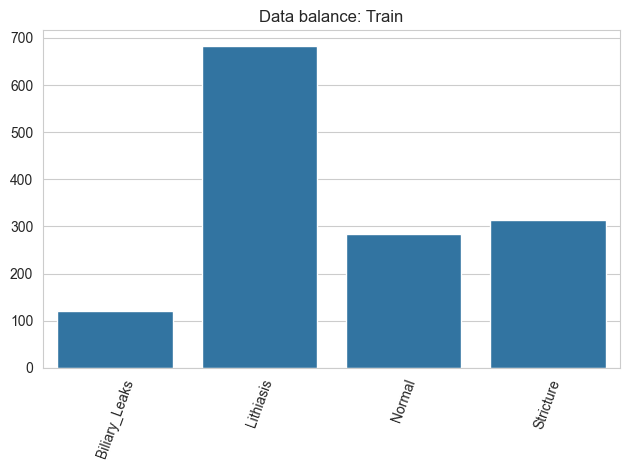

----- VALIDATION CASES -----
cases: 244
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 15 134  55  40]
244


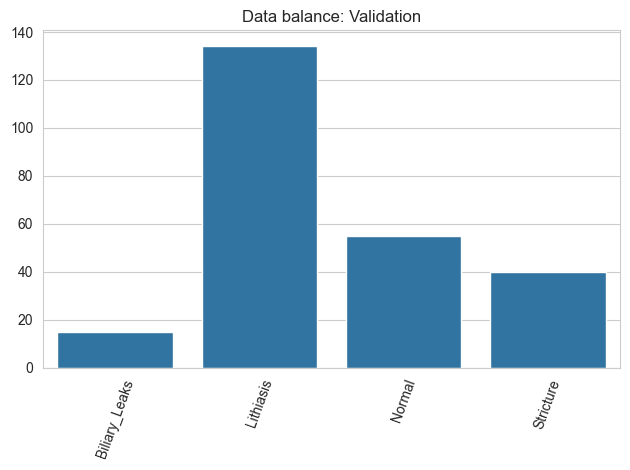

----- TEST CASES -----
cases: 246
['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
['0', '1', '2', '3']
[ 15 136  56  39]
246


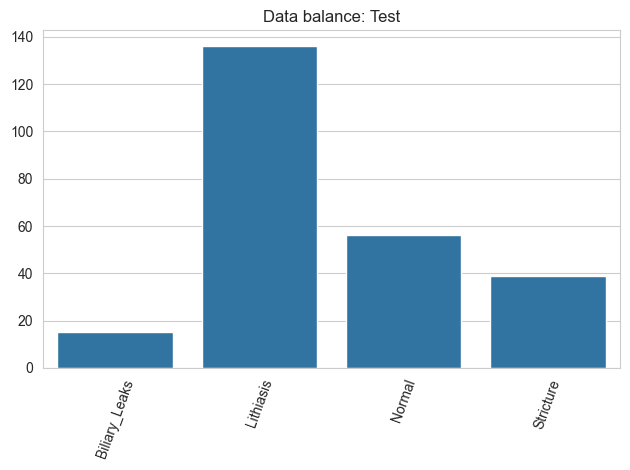

In [7]:
def visualize_holdout_balance(labels, class_names, header):
    sns.set_style('whitegrid')
    print("cases:", len(labels))
    x, y = np.unique(labels, return_counts=True)
    x_ext=[class_names[n]  for n in x]
    print(x_ext)
    print([str(n) for n in x])
    print(y)
    print(np.sum(y))
    grafico=sns.barplot(x=x_ext, y=y)
    grafico.set_title(f'Data balance: {header}')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

print("----- TRAIN CASES -----")
visualize_holdout_balance(data['train']['labels'], class_names, 'Train')
print("----- VALIDATION CASES -----")
visualize_holdout_balance(data['val']['labels'], class_names, 'Validation')
print("----- TEST CASES -----")
visualize_holdout_balance(data['test']['labels'], class_names, 'Test')


## Transforms
Define data augmentation and preprocessing for training and validation. Images are resized to 512×512.

In [8]:
class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img
    
from skimage import exposure
import numpy as np
import torch

class ApplyCLAHE:
    def __init__(self, clip_limit=0.01):
        self.clip_limit = clip_limit

    def __call__(self, img):
        # Converte para numpy array
        img_np = img.numpy() if isinstance(img, torch.Tensor) else img
        
        # 1. Normalizar a imagem para o intervalo [0, 1] para o skimage não dar erro
        img_min = img_np.min()
        img_max = img_np.max()
        
        # Evitar divisão por zero caso a imagem seja toda preta
        if img_max > img_min:
            img_norm = (img_np - img_min) / (img_max - img_min)
        else:
            img_norm = img_np
            
        img_out = np.zeros_like(img_norm, dtype=np.float32)
        
        # 2. Aplicar o CLAHE de forma segura
        for i in range(img_norm.shape[0]):
            img_out[i] = exposure.equalize_adapthist(img_norm[i], clip_limit=self.clip_limit)
            
        # 3. Restaurar a escala original (ex: de volta para 0-255)
        img_out = img_out * (img_max - img_min) + img_min
        
        # 4. Devolver no mesmo formato que recebeu (MetaTensor do MONAI)
        if isinstance(img, torch.Tensor):
            if hasattr(img, 'as_tensor'):
                img_novo = img.clone()
                img_novo[:] = torch.from_numpy(img_out).to(img.dtype)
                return img_novo
            return torch.from_numpy(img_out).to(img.dtype)
        
        return img_out

train_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((384, 384)),
    ApplyCLAHE(clip_limit=0.01),
    RandRotate(range_x=15, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    RandAdjustContrast(prob=0.5),
    RandGaussianNoise(prob=0.3, mean=0.0, std=0.01),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    ApplyCLAHE(clip_limit=0.01),
    Resize((384, 384)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

act = Activations(softmax=True)
to_onehot = AsDiscrete(to_onehot=num_class)

## Dataset & DataLoaders
Wrap file paths into a Dataset and create DataLoaders for training, validation and testing.

In [9]:
class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image = self.image_files[index]
        return self.transforms(image), self.labels[index]

train_ds = MedNISTDataset(data['train']['images'], data['train']['labels'], train_transforms)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(data['val']['images'], data['val']['labels'], val_transforms)
val_loader = DataLoader(val_ds, batch_size=4, num_workers=0)

test_ds = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=4, num_workers=0)

## Model
Instantiate an DeiTIII backbone (pretrained) and adapt the classifier head to the number of classes.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('deit3_small_patch16_384', pretrained=True, in_chans=3)
model.head = nn.Linear(model.head.in_features, num_class)
model = model.to(device)

C:\Users\bruno\AppData\Local\Temp\ipykernel_12528\117565044.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('deitiii_CLAHE.pth'))


DeiT-III (Treinado) configurado como Extrator de Features.

A extrair features do conjunto de Treino (isto pode demorar uns minutos)...
A extrair features do conjunto de Validação...
Extração concluída em 122.89 segundos!

A iniciar o treino do XGBoost...
Treino do XGBoost concluído em 6.37 segundos!

 🎯 AUC-ROC SCORE (DeiT-III): 0.8182 


 🚀 F1-SCORE MACRO ALCANÇADO: 0.5879 
 (Objetivo a superar: 0.7380)

Relatório de Classificação Detalhado:
               precision    recall  f1-score   support

Biliary_Leaks       0.56      0.60      0.58        15
    Lithiasis       0.71      0.78      0.75       134
       Normal       0.62      0.42      0.50        55
    Stricture       0.50      0.55      0.52        40

     accuracy                           0.65       244
    macro avg       0.60      0.59      0.59       244
 weighted avg       0.65      0.65      0.64       244



c:\Users\bruno\Desktop\Uni\MIA\Aprendizagem Profunda\Módulo II\Aprendizagem-Profunda---Trabalho-Pratico\venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [13:45:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


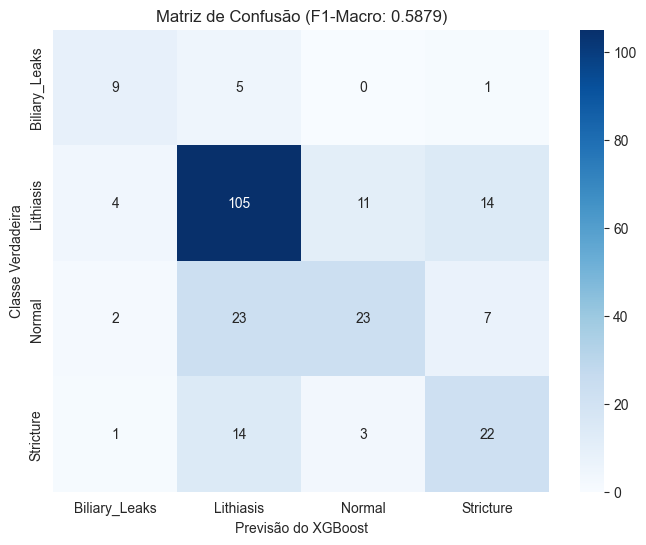

In [11]:
import torch
import torch.nn as nn
import numpy as np
import time
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

# ==============================================================================
# FASE 1: PREPARAR O DEIT COMO EXTRATOR DE FEATURES
# ==============================================================================
# 1. Criar o modelo base
model = timm.create_model('deit3_small_patch16_384', pretrained=False, in_chans=3)

# 2. Ajustar a cabeça para ter 4 classes (igual ao teu treino original!)
# Nota: o num_class aqui é 4, correspondente às tuas 4 doenças
model.head = nn.Linear(model.head.in_features, 4)

# 3. CARREGAR A "INTELIGÊNCIA" MÉDICA (Agora já vai encaixar perfeitamente)
model.load_state_dict(torch.load('deitiii_CLAHE.pth'))

# 4. Cortar a cabeça e transformar em extrator de features
model.head = nn.Identity()
model = model.to(device)
model.eval()
print("DeiT-III (Treinado) configurado como Extrator de Features.")

# ==============================================================================
# FASE 2: EXTRAÇÃO DOS VETORES
# ==============================================================================
def extract_features(dataloader, model, device):
    features, labels_list = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            features.append(outputs.cpu().numpy())
            labels_list.append(labels.cpu().numpy())
            
    return np.concatenate(features, axis=0), np.concatenate(labels_list, axis=0)

starttime = time.perf_counter()
print("\nA extrair features do conjunto de Treino (isto pode demorar uns minutos)...")
X_train, y_train = extract_features(train_loader, model, device)

print("A extrair features do conjunto de Validação...")
X_val, y_val = extract_features(val_loader, model, device)
print(f"Extração concluída em {time.perf_counter() - starttime:.2f} segundos!")

# ==============================================================================
# FASE 3: TREINAR O XGBOOST COM PESOS PARA DESBALANCEAMENTO
# ==============================================================================
# Aqui resolvemos o problema de ter poucas Biliary_Leaks e muitas Lithiasis
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print("\nA iniciar o treino do XGBoost...")
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    tree_method='hist',   # Método muito rápido
    device='cuda',        # Tira partido da tua RTX 4060
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_starttime = time.perf_counter()
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
print(f"Treino do XGBoost concluído em {time.perf_counter() - xgb_starttime:.2f} segundos!")

# ==============================================================================
# FASE 4: AVALIAÇÃO E MATRIZ DE CONFUSÃO
# ==============================================================================
# Fazer previsões
y_pred = xgb_model.predict(X_val)

y_pred_proba = xgb_model.predict_proba(X_val)

auc_roc = roc_auc_score(y_val, y_pred_proba, multi_class='ovr', average='macro')

#for i in range(len(y_val)):
#    print(f"Probabilidades para a Imagem {i + 1}:")
#    for classe, prob in zip(classes_alvo, y_pred_proba[i]):
#        print(f"{classe}: {prob * 100:.2f}%")

print(f"\n==================================================")
print(f" 🎯 AUC-ROC SCORE (DeiT-III): {auc_roc:.4f} ")
print(f"==================================================\n")

# Calcular o tão desejado F1-Score Macro
f1_macro = f1_score(y_val, y_pred, average='macro')
print(f"\n==================================================")
print(f" 🚀 F1-SCORE MACRO ALCANÇADO: {f1_macro:.4f} ")
print(f" (Objetivo a superar: 0.7380)")
print(f"==================================================\n")

print("Relatório de Classificação Detalhado:")
nomes_classes = ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
print(classification_report(y_val, y_pred, target_names=nomes_classes))

# Desenhar a Matriz de Confusão (perfeito para colocares no relatório do artigo)
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.ylabel('Classe Verdadeira')
plt.xlabel('Previsão do XGBoost')
plt.title(f'Matriz de Confusão (F1-Macro: {f1_macro:.4f})')
plt.show()

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. FUNÇÃO DE OCLUSÃO PARA MODELOS HÍBRIDOS
# ==============================================================================
def hybrid_occlusion_heatmap(image_tensor, label_idx, cnn_model, xgb_model, patch_size=32, stride=16):
    cnn_model.eval()
    _, C, H, W = image_tensor.shape
    
    # 1. Probabilidade Base (sem nada tapado)
    with torch.no_grad():
        baseline_feat = cnn_model(image_tensor).cpu().numpy()
    baseline_prob = xgb_model.predict_proba(baseline_feat)[0, label_idx]
    
    # 2. Preparar a grelha do mapa de calor
    grid_h, grid_w = (H // stride), (W // stride)
    heatmap = np.zeros((grid_h, grid_w))
    
    print("A gerar o mapa de oclusão (a deslizar o quadrado pela imagem)...")
    
    # 3. Deslizar o quadrado preto pela imagem
    for i in range(grid_h):
        for j in range(grid_w):
            y1, y2 = i * stride, min(i * stride + patch_size, H)
            x1, x2 = j * stride, min(j * stride + patch_size, W)
            
            # Criar a imagem com a zona tapada (zeros = preto)
            occluded_img = image_tensor.clone()
            occluded_img[:, :, y1:y2, x1:x2] = 0.0 
            
            # Extrair features da imagem tapada e ver a nova probabilidade
            with torch.no_grad():
                feat = cnn_model(occluded_img).cpu().numpy()
            prob = xgb_model.predict_proba(feat)[0, label_idx]
            
            # A importância desta zona é o quanto a probabilidade CAIU
            heatmap[i, j] = baseline_prob - prob
            
    # 4. Redimensionar o mapa de calor para o tamanho da imagem original
    heatmap = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0) 
    heatmap_resized = F.interpolate(heatmap, size=(H, W), mode='bilinear', align_corners=False)
    heatmap_resized = heatmap_resized.squeeze().numpy()
    
    # Normalizar (ignorar zonas que não importam e escalar de 0 a 1)
    heatmap_resized = np.maximum(heatmap_resized, 0)
    if np.max(heatmap_resized) > 0:
        heatmap_resized /= np.max(heatmap_resized)
        
    return heatmap_resized, baseline_prob

# ==============================================================================
# 2. SELECIONAR UMA IMAGEM DE TESTE E GERAR A VISUALIZAÇÃO
# ==============================================================================
# Vamos buscar a primeira imagem do Test Loader (podes rodar para outras imagens depois)
images, labels = next(iter(test_loader))
img_tensor = images[0:1].to(device)
true_label = labels[0].item()
nome_da_doenca = nomes_classes[true_label]

# Gerar o Heatmap
heatmap, prob_base = hybrid_occlusion_heatmap(img_tensor, true_label, model, best_xgb_model, patch_size=64, stride=32)

# Desfazer a normalização da imagem para conseguirmos visualizá-la corretamente
img_display = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

# ==============================================================================
# 3. DESENHAR O RESULTADO
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imagem Original
axes[0].imshow(img_display)
axes[0].set_title(f"Raio-X Original\nClasse Verdadeira: {nome_da_doenca}")
axes[0].axis('off')

# Imagem + Mapa de Calor
axes[1].imshow(img_display)
# Sobrepor o heatmap (usamos o colormap 'jet' que vai do azul ao vermelho escuro)
im = axes[1].imshow(heatmap, cmap='jet', alpha=0.5) 
axes[1].set_title(f"Occlusion Heatmap\nCerteza do Modelo: {prob_base*100:.1f}%")
axes[1].axis('off')

# Adicionar a barra de cores
cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Importância para a Decisão', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()